# Algoritmos 

## Particle Swarm Optimization (PSO)



In [1]:
from ene300.functions import shubert, griewank, sixhump, easom, eggholder
from ene300.optimization import PSO
from ene300.plot import animate_pso, plot_surface

%matplotlib inline

In [2]:
import numpy as np

def custo(x):

    a = np.array([26.97, 1.865, 39.79])
    b = np.array([-0.3975, -0.03988, -0.3116])
    c = np.array([0.002176, 0.001138, 0.001457])
    
    PG = x
    F = 0
    for i in range(3):
        F += a[i] + b[i]*PG[i]+c[i]*PG[i]**2
    return F

In [3]:
def custo_regularizado(x, alpha=10):
    return custo(x) + alpha*(np.sum(x, axis=0)-550)**2

# Análise Estatística

In [4]:
other_params = dict(velocity_boundary = [-1,1],
                    weight_function = dict(function='sigmoidal_increase', start=0, end=2, n=0.5, u_sign=0.15) , 
                    C_function = [ dict(function='constant', constant=1.0),
                                   dict(function='constant', constant=1.5)  ],
                    population = 50,
                    itmax = 100)

optimization_algorithm = PSO()

functions_params = {
    'shubert' :            dict( objective_function = shubert,
                                position_boundary = [[-10, 10],   [-10, 10]  ] ),
    'griewank' :           dict( objective_function = griewank,
                                position_boundary = [[-60, 60],   [-60, 60]  ] ),
    'sixhump' :            dict( objective_function = sixhump,
                                position_boundary = [[-3, 3],     [-2, 2]    ] ),
    'easom' :              dict( objective_function = easom,
                                position_boundary = [[-100, 100], [-100, 100]] ),
    'eggholder' :          dict( objective_function = eggholder,
                                position_boundary = [[-512, 512], [-512, 512]] ),
    'custo_regularizado' : dict( objective_function = custo_regularizado,
                                position_boundary = [[100, 196],  [50, 114]  , [200, 332]] ),
    }

Nruns = 20
statistics = {}
for function, function_params in functions_params.items():
    statistics[function] = {}
    statistics[function]['history'] = []
    statistics[function]['Nruns'] = Nruns
    
    #statistics[function]['global_best'] = []
    #statistics[function]['best_fit'] = []
    #statistics[function]['cpu_time'] = []
    
    #statistics[function]['history'] = []
    for i in range(Nruns):
        global_best, best_fit, history = optimization_algorithm(**function_params, **other_params)
        #statistics[function]['global_best'].append( list(global_best) )
        #statistics[function]['best_fit'].append( float(best_fit))
        #statistics[function]['cpu_time'].append( float(history['cpu_time']))
        statistics[function]['history'].append(history)
        
    #statistics[function]['global_best'] = np.array(statistics[function]['global_best'])
    #statistics[function]['best_fit'] = np.array(statistics[function]['best_fit'])
    #statistics[function]['cpu_time'] = np.array(statistics[function]['cpu_time'])
    statistics[function]['history'] = np.array(statistics[function]['history'])

In [114]:
def get_history(statistics, key, idx=None):
    if idx is None:
        ret = []
        for i in range(statistics['Nruns']):
            ret.append(get_history(statistics, key, i))
    else:
        ret = statistics['history'][idx][key]
    ret = np.array(ret)
    return ret
    
def get_last(statistics, key, idx=None):
    if idx is None:
        ret = []
        for i in range(statistics['Nruns']):
            ret.append(get_last(statistics, key, i))
    else:
        ret = statistics['history'][idx][key][-1]
    ret = np.array(ret)
    return ret

def metric(x, y):
    return rse(x,y)

def rse(x, y):
    return np.sqrt((x-y)**2)

In [116]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x7f290b3f8af0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f290b387070>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f290b3f8850>],
 'medians': [<matplotlib.lines.Line2D at 0x7f290b387490>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f290b387730>],
 'means': []}

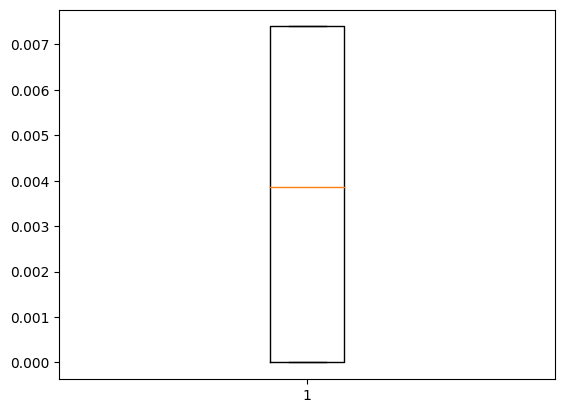

In [124]:

function_names = ['shubert', 'griewank', 'sixhump', 'easom', 'eggholder', 'custo_regularizado']
function_references = [-186.7309, 0.0, -1.0316, -1.0, -959.640, 250.0]

function_names = function_names[1:2]
function_references = function_references[1:2]


plt.boxplot( [metric(get_last(statistics[fun], 'best_fit'), ref) for fun,ref in zip(function_names, function_references)] )
